# Relationship between GDP per capita and life expecatay in Ethiopia 

# 1. Motivation
As defined by the World Bank, life expectancy at birth is the average number of years a newborn is expected to live if mortality patterns at the time of its birth remain constant in the future. It reflects the overall mortality level of a population, and summarizes the mortality pattern that prevails across all age groups in a given year. Life expectancy refers to the number of years a person is expected to live based on the statistical average. Before the modernization of the world, life expectancy was around 30 years in all parts of the world. Life expectancy increased at the beginning of the 19th. Studies indicate that Gross Domestic Product (GDP) per capita increases the life expectancy at birth through increasing economic growth and development in a country and thus leads to the prolongation of longevity.In other words, this means as GDP per capita increase, life expectancy also increases. Yet in recent years, accumulating evidence suggests that rising incomes and personal well-being are linked in the opposite way. It seems that economic growth actually kills people. An article published in the World Economic forum website shows that when GDP grows about 5 percent above trend adults are about 1 percent more likely to die. By analysing the relationship of GDP per capita and life expectancy, this project aims to shade light on this conflicting findings.

I selected Ethiopia just because I am from Ethiopia and hence familiar with the context of the country. 

# 2. Research question
How does life expectancy relate to GDP per capita in Ethiopia? 

# 3. Import libraries
Let us begin by importing the libraries to be used in the analyis. They include numpy, pandas for dataframe and dataseries and matplotlib for visualization.

In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# 4. Data reading and initial exploration
This section reads the dataset to be used and presents basic information about the data. The file name of the dataset is WDIData_T.csv.

In [6]:
dataset = pd.read_csv('WDIData_T.csv')
dataset.shape 

(7578806, 6)

In [54]:
dataset.isnull().any()

CountryName      False
CountryCode      False
IndicatorName    False
IndicatorCode    False
Year             False
Value            False
dtype: bool

In [7]:
dataset.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
0,Arab World,ARB,"Adolescent fertility rate (births per 1,000 wo...",SP.ADO.TFRT,1960,134.772341
1,Arab World,ARB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,1960,88.061110
2,Arab World,ARB,"Age dependency ratio, old (% of working-age po...",SP.POP.DPND.OL,1960,6.591951
3,Arab World,ARB,"Age dependency ratio, young (% of working-age ...",SP.POP.DPND.YG,1960,81.324186
4,Arab World,ARB,Aquaculture production (metric tons),ER.FSH.AQUA.MT,1960,4600.000000


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7578806 entries, 0 to 7578805
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   CountryName    object 
 1   CountryCode    object 
 2   IndicatorName  object 
 3   IndicatorCode  object 
 4   Year           int64  
 5   Value          float64
dtypes: float64(1), int64(1), object(4)
memory usage: 346.9+ MB


The dataset contains more than 7,578,806 raws and 6 columns and has three data types (float = 1, integer = 1 and object = 4).  

In [9]:
print(dataset. describe())

               Year         Value
count  7.578806e+06  7.578806e+06
mean   1.996822e+03  1.377970e+12
std    1.539543e+01  7.246749e+13
min    1.960000e+03 -9.824821e+15
25%    1.986000e+03  5.744782e+00
50%    2.000000e+03  4.501830e+01
75%    2.010000e+03  1.785338e+05
max    2.020000e+03  1.590415e+16


In [10]:
# How many unique country names does the dataset contain? 
countries = dataset['CountryName'].unique().tolist()
len(countries)

263

There are 263 unique countries in the dataset. 

In [11]:
# How many unique country codes does the dataset contain?
CountryCodes = dataset['CountryCode'].unique().tolist()
len(CountryCodes)

263

In [12]:
# How many unique indicators does the dataset contain?
indicators = dataset['IndicatorName'].unique().tolist()
len(indicators)

1437

The dataset consists of 1437 unique indicators. 

In [13]:
# How many years of data does the dataset have?
years = dataset['Year'].unique().tolist()
len(years)

61

In [14]:
# Period coverage of the dataset
print(min(years)," to ",max(years))

1960  to  2020


The datset contains 61 yeras of data covering the period 1960 to 2020. 

# 5. Data visualization

## Selecting indicators and country for the analysis
This part selects the life expectancy at birth as measured by total number of years and GDP per capita as indicators for Ethiopia. 

In [41]:
# Selecting life expectancy (LE) and GDP per capita for Ethiopia
LE_country = 'ETH'
LE_indicator = 'Life expectancy at birth, total \(years'
gdp_indicator = 'GDP per capita \(constant 2010'

mask1 = dataset['CountryCode'].str.contains(LE_country)
mask2 = dataset['IndicatorName'].str.contains(LE_indicator)
mask3 = dataset['IndicatorName'].str.contains(gdp_indicator)

In [42]:
mask1.value_counts()

False    7546503
True       32303
Name: CountryCode, dtype: int64

In [17]:
mask2.value_counts()

False    7564561
True       14245
Name: IndicatorName, dtype: int64

In [18]:
mask3.value_counts()

False    7566919
True       11887
Name: IndicatorName, dtype: int64

In [19]:
# apply mask for country code, life expectancy and GDP per capita.
LE_data = dataset[mask1 & mask2]
GDP_pc_data = dataset[mask1 & mask3]

In [20]:
LE_data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
16388,Ethiopia,ETH,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,38.419
56011,Ethiopia,ETH,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,39.082
99084,Ethiopia,ETH,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,39.711
143320,Ethiopia,ETH,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,40.290
187646,Ethiopia,ETH,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,40.810


In [21]:
# How many years of LE data do we have?
years = LE_data['Year'].unique().tolist()
len(years)

59

In [22]:
# Period coverage of the LE_data
print(min(years)," to ",max(years))

1960  to  2018


In [23]:
print(LE_data. describe())

              Year      Value
count    59.000000  59.000000
mean   1989.000000  49.535288
std      17.175564   8.142028
min    1960.000000  38.419000
25%    1974.500000  43.702500
50%    1989.000000  46.667000
75%    2003.500000  54.692500
max    2018.000000  66.240000


In [72]:
# How many years of GDP per capita data do we have?
years = GDP_pc_data['Year'].unique().tolist()
len(years)

39

In [73]:
print(min(years)," to ",max(years))

1981  to  2019


## The evolution of life expecatancy and GDP per capita over time
As shown in Figure 1, life expectancy in Ethiopia has generally seen an an increasing trend over the period 1960 - 2018. On the other hand, GDP per capita has shown a fluctuating trend until 2000s after which it has steadly moved upwards.  

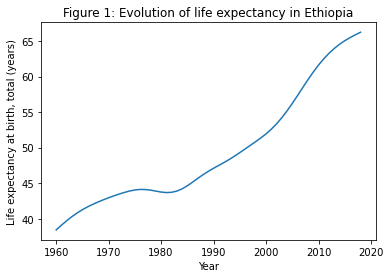

In [130]:
# # Let's see the evolution of life expectancy in Ethiopia using a line plot
plt.plot(LE_data['Year'].values, LE_data['Value'].values)

# Label the axes
plt.xlabel('Year')
plt.ylabel(LE_data['IndicatorName'].iloc[0])

#label the figure
plt.title('Figure 1: Evolution of life expectancy in Ethiopia')

# to make more honest, start the y axis at 0
# plt.axis([1959, 2011,0,25])

plt.show()

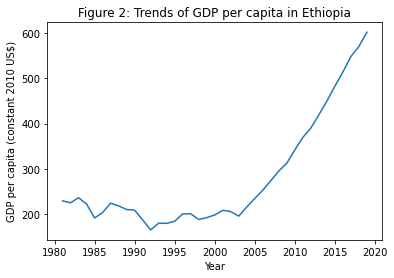

In [131]:
# Let's see the trends of GDP per capita in Ethiopia using a line plot
plt.plot(GDP_pc_data['Year'].values, GDP_pc_data['Value'].values)

# Label the axes
plt.xlabel('Year')
plt.ylabel(GDP_pc_data['IndicatorName'].iloc[0])

#label the figure
plt.title('Figure 2: Trends of GDP per capita in Ethiopia')


plt.show()

## Life expectancy by income group
The datset contains life expectancy data by income group designated as Low Income Countries (LIC), Lower Middle Income Countries (LMC), Middle Income Countries (MIC) and High Income Countries (HIC). To put life expectancy into perspective, I presented the life expectancy by the four income groups in Figure 3. To see how far it is from the rest of the group, Ethiopia's data is also depicted. Accordingly, the figure shows that life expectancy of high income countries is far higher followed by those of middle income countries. Although there appears to be an increasing trend, low income countries remain at the bottom of the group. Ethiopia's trend of life expectancy remained below those of low income countries average until towards the end of the 2000s after which the formers trend surpassed that of the later.  

In [28]:
# Selecting life expectancy (LE) and GDP per capita by income group
LE_indicator = 'Life expectancy at birth, total \(years'
LE_country = 'LIC'
LE_country2 = 'LMC'
LE_country3 = 'MIC'
LE_country4 = 'HIC'


mask1 = dataset['IndicatorName'].str.contains(LE_indicator)
mask2 = dataset['CountryCode'].str.contains(LE_country)
mask3 = dataset['CountryCode'].str.contains(LE_country2)
mask4 = dataset['CountryCode'].str.contains(LE_country3)
mask5 = dataset['CountryCode'].str.contains(LE_country4)

# Applying mask
LIC_data = dataset[mask1 & mask2]
LMC_data = dataset[mask1 & mask3]
MIC_data = dataset[mask1 & mask4]
HIC_data = dataset[mask1 & mask5]

# gdp_indicator = 'GDP per capita \(constant 2010'

In [29]:
LIC_data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
4193,Low income,LIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,39.724770
42358,Low income,LIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,40.162719
84688,Low income,LIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,40.594861
129002,Low income,LIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,41.030433
173241,Low income,LIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,41.476848


In [30]:
LMC_data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
4361,Lower middle income,LMC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,45.118916
42544,Lower middle income,LMC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,45.699591
84883,Lower middle income,LMC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,46.272609
129196,Lower middle income,LMC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,46.837387
173436,Lower middle income,LMC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,47.391866


In [31]:
MIC_data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5020,Middle income,MIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,47.584682
43275,Middle income,MIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,48.110172
85634,Middle income,MIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,48.720213
129947,Middle income,MIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,49.443575
174180,Middle income,MIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,50.288962


In [32]:
HIC_data.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
2207,High income,HIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1960,68.465128
40162,High income,HIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1961,68.856728
82389,High income,HIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1962,68.847605
126729,High income,HIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1963,69.059102
170956,High income,HIC,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,1964,69.450570


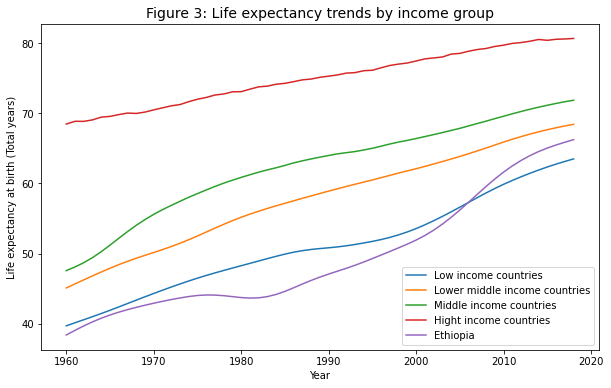

In [132]:
fig, ax = plt.subplots(figsize=(10, 6))
# Grid lines, Xticks, Xlabel, Ylabel

axis.yaxis.grid(True)

ax.plot(LIC_data['Year'].values, LIC_data['Value'].values, label="Low income countries")
ax.plot(LMC_data['Year'].values, LMC_data['Value'].values, label="Lower middle income countries")
ax.plot(MIC_data['Year'].values, MIC_data['Value'].values, label="Middle income countries")
ax.plot(HIC_data['Year'].values, HIC_data['Value'].values, label="Hight income countries")
ax.plot(LE_data['Year'].values, LE_data['Value'].values, label="Ethiopia")

ax.set_title('Figure 3: Life expectancy trends by income group', fontsize=14)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Life expectancy at birth (Total years)', fontsize=10)

ax.legend(loc = 'lower right')

plt.show()

## Evaluate correlation between GDP and life expectancy.
We could also visualize this data as a histogram to better explore the ranges of values in CO2 production per year. To see how life expectancy in different countries is distributed, let's create a histogram of

as per above graph, we can see Life Expectancy is getting higher when GDP per Capita is high. To know more, we need to know correlationship between GDP per Capita and Life Expectancy.
When you have a time scale along the horizontal axis, the line plot is your friend. But in many other cases, when you're trying to assess if there's a correlation between two variables, for example, the scatter plot is the better choice. Below is an example of how to build a scatter plot.

Finally, we can explore how these variables are related by plotting a scatter plot of GDP per capita vs Life Expectancy for each country. I've chosen the year 2007 for being the most recent sample.

By modifying the scale of the x-axis to log one, we can bypass the accumulation of data points, making data visualization more friendly to the eye.

It seems that higher GDP per capita is likely to be transalted into higher life expectancy.

I looked at the general levels of the regions in 2016 by using boxplots. The figures show that when the income per capita is high, regions have low infant mortality and fertility rates.

In [83]:
# select life expectancy for all countries in 2011
LE_gdppc_year = 2011
LE_indicator = 'Life expectancy at birth, total \(years'
gdppc_indicator = 'GDP per capita \(constant 2010'

mask1 = dataset['Year'].isin([LE_gdppc_year])
mask2 = dataset['IndicatorName'].str.contains(LE_indicator)
mask3 = dataset['IndicatorName'].str.contains(gdppc_indicator)

# apply our mask
LE_data2011 = dataset[mask1 & mask2]
gdppc_data2011 = dataset[mask1 & mask3]


In [81]:
LE_data2018.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
7292390,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2018,71.806825
7292954,Caribbean small states,CSS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2018,73.637108
7293539,Central Europe and the Baltics,CEB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2018,76.976845
7294143,Early-demographic dividend,EAR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2018,70.483191
7294793,East Asia & Pacific,EAS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2018,76.068336


In [84]:
LE_data2011.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5855741,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,70.528775
5856401,Caribbean small states,CSS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,72.795298
5857096,Central Europe and the Baltics,CEB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,75.888475
5857795,Early-demographic dividend,EAR,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,68.438906
5858529,East Asia & Pacific,EAS,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2011,74.265950


In [86]:
print(len(LE_data2011))

246


In [87]:
gdppc_data2011.head()

,CountryName,CountryCode,IndicatorName,IndicatorCode,Year,Value
5855633,Arab World,ARB,GDP per capita (constant 2010 US$),NY.GDP.PCAP.KD,2011,6020.486894
5856312,Caribbean small states,CSS,GDP per capita (constant 2010 US$),NY.GDP.PCAP.KD,2011,9118.640470
5856964,Central Europe and the Baltics,CEB,GDP per capita (constant 2010 US$),NY.GDP.PCAP.KD,2011,13015.317074
5857672,Early-demographic dividend,EAR,GDP per capita (constant 2010 US$),NY.GDP.PCAP.KD,2011,3045.718458
5858413,East Asia & Pacific,EAS,GDP per capita (constant 2010 US$),NY.GDP.PCAP.KD,2011,7999.303164


In [88]:
print(len(gdppc_data2011))

248


In [71]:
pd.unique(dataset[['CountryCode']].values.ravel())

array(['ARB', 'CSS', 'CEB', 'EAR', 'EAS', 'EAP', 'TEA', 'EMU', 'ECS',
       'ECA', 'TEC', 'EUU', 'FCS', 'HPC', 'HIC', 'IBD', 'IBT', 'IDB',
       'IDX', 'IDA', 'LTE', 'LCN', 'LAC', 'TLA', 'LDC', 'LMY', 'LIC',
       'LMC', 'MEA', 'MNA', 'TMN', 'MIC', 'NAC', 'OED', 'OSS', 'PSS',
       'PST', 'PRE', 'SST', 'SAS', 'TSA', 'SSF', 'SSA', 'TSS', 'UMC',
       'WLD', 'AFG', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'ATG', 'ARG',
       'ARM', 'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB',
       'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BIH', 'BWA',
       'BRA', 'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'CPV', 'KHM', 'CMR',
       'CAN', 'CYM', 'CAF', 'TCD', 'CHI', 'CHL', 'CHN', 'COL', 'COM',
       'COD', 'COG', 'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE',
       'DNK', 'DJI', 'DMA', 'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI',
       'EST', 'SWZ', 'ETH', 'FRO', 'FJI', 'FIN', 'FRA', 'PYF', 'GAB',
       'GMB', 'GEO', 'DEU', 'GHA', 'GIB', 'GRC', 'GRL', 'GRD', 'GUM',
       'GTM', 'GIN',

### Scatter plot for Ethiopia

In [89]:
print("GDP Min Year = ", GDP_pc_data['Year'].min(), "max: ", GDP_pc_data['Year'].max())
print("LE Min Year = ", LE_data['Year'].min(), "max: ", LE_data['Year'].max())

GDP Min Year =  1981 max:  2019
LE Min Year =  1960 max:  2018


In [90]:
GDP_pc_data_trim = GDP_pc_data[GDP_pc_data['Year'] < 2019]
LE_data_trim = LE_data[LE_data['Year'] >= 1981]
print(len(GDP_pc_data_trim))
print(len(LE_data_trim))

38
38


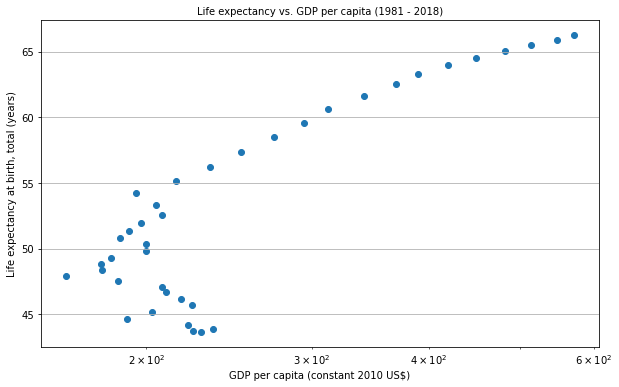

In [119]:
fig, axis = plt.subplots(figsize=(10, 6))
# Grid lines, Xticks, Xlabel, Ylabel

axis.yaxis.grid(True)
axis.set_title('Life expectancy vs. GDP per capita (1981 - 2018)',fontsize=10)
axis.set_xlabel(GDP_pc_data_trim['IndicatorName'].iloc[0],fontsize=10)
axis.set_ylabel(LE_data_trim['IndicatorName'].iloc[0],fontsize=10)
axis.set(xscale ="log")
# plt.yticks([30, 35, 40, 45, 55, 60, 65])

X = GDP_pc_data_trim['Value']
Y = LE_data_trim['Value']

axis.scatter(X, Y, alpha = 1)
plt.show()

#### This doesn't look like a strong relationship. We can test this by looking at correlation.
As expected, there appears to be a strong correlation between life expectancy and GDP per capita. We can further test this using correlation coefficienct. Accordingly, we find that a strong correlation of 0.85 between the two.

In [97]:
np.corrcoef(GDP_pc_data_trim['Value'], LE_data_trim['Value'])

array([[1.        , 0.84788232],
       [0.84788232, 1.        ]])

here’s a strong relationship between GDP and life expectancy, suggesting that more money is better